# Clustering

## Objetivos de aprendizaje

Al finalizar este capítulo, el lector podrá:

- explicar la intuición y el criterio de optimización de K-means, K-medoides, clustering aglomerativo y DBSCAN;
- reconocer por qué la escala de las variables afecta los métodos basados en distancias;
- distinguir entre métodos de partición, jerárquicos y basados en densidad;
- evaluar una solución de clustering mediante el coeficiente de Silueta y el índice de Calinski–Harabasz;
- interpretar los puntos de ruido identificados por DBSCAN.


Un **clúster** es una agrupación de observaciones que presentan mayor similitud entre sí que con las observaciones de otros grupos. El objetivo general del clustering es descubrir estructuras subyacentes en datos sin utilizar una variable objetivo conocida.

> Una buena agrupación busca alta cohesión interna —observaciones parecidas dentro de cada clúster— y alta separación externa —clústeres distintos entre sí—.

Sea

$$
\mathbf{X}=\{\mathbf{x}_1,\mathbf{x}_2,\ldots,\mathbf{x}_N\}
$$

un conjunto de $N$ observaciones, donde cada vector $\mathbf{x}_i=(x_{i1},x_{i2},\ldots,x_{id})\in\mathbb{R}^d$ contiene $d$ características. Una partición dura de $\mathbf{X}$ en $K$ clústeres se representa mediante

$$
\mathcal{C}=\{C_1,C_2,\ldots,C_K\},
$$

y debe cumplir:

- **No vacuidad:** $C_k\neq\emptyset$ para todo $k=1,\ldots,K$.
- **Cobertura:** $\bigcup_{k=1}^{K}C_k=\mathbf{X}$.
- **Exclusividad:** $C_k\cap C_\ell=\emptyset$ para todo $k\neq\ell$.

La calidad de una agrupación depende del objetivo del análisis, de la representación de los datos, de la métrica de distancia y del algoritmo utilizado. Por ello, no existe un método universalmente mejor para todos los conjuntos de datos.


## K-means

K-means es uno de los métodos de agrupación más utilizados. Representa cada clúster mediante un **centroide**, es decir, el promedio de las observaciones asignadas al grupo.

Su objetivo es minimizar la suma de cuadrados dentro de los clústeres:

$$
J(\mathcal{C},\boldsymbol{\mu})
=
\sum_{k=1}^{K}
\sum_{\mathbf{x}_i\in C_k}
\left\|\mathbf{x}_i-\boldsymbol{\mu}_k\right\|_2^2,
$$

donde $\boldsymbol{\mu}_k$ es el centroide del clúster $C_k$. Una menor función objetivo implica grupos internamente más compactos.

K-means funciona especialmente bien cuando los clústeres son aproximadamente compactos, de tamaño comparable y separables mediante distancia euclidiana. Puede presentar dificultades ante valores atípicos, variables en escalas muy diferentes o grupos con formas no esféricas.


### Librerías

Las principales librerías utilizadas en este capítulo son:

- `numpy` y `pandas`, para manipulación de datos;
- `matplotlib`, para visualización;
- `scikit-learn`, para K-means, clustering aglomerativo, DBSCAN y métricas de evaluación;
- `scipy`, para matrices de distancias, enlaces jerárquicos y dendrogramas;
- `scikit-learn-extra`, para K-medoides.


### Ejemplo 

Veamos un ejemplo de k-means mediante la generación de clústers aleatorios (`make_blobs`) y `k=3`.

**Preámbulo y datos**

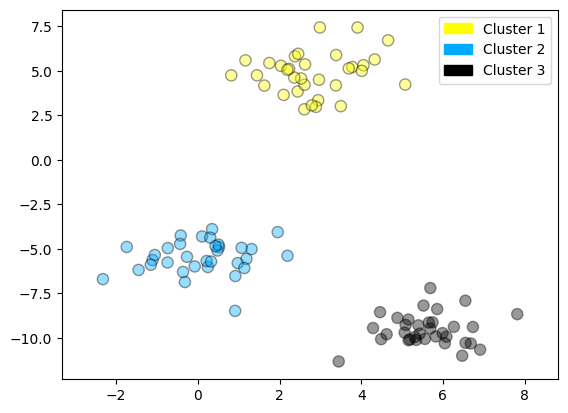

In [6]:
# %matplotlib notebook
# Esta línea permite gráficos interactivos en Jupyter Notebook. Comentada actualmente.

import numpy as np                  # Librería para cálculos numéricos y manejo de arreglos.
import pandas as pd                # Librería para manipulación de datos tipo tabla (DataFrame).
import seaborn as sns               # Librería para visualizaciones estadísticas (no usada aquí).
import matplotlib.pyplot as plt    # Librería para generar gráficos y visualizaciones.

from sklearn.datasets import make_blobs  # Función para generar datos de prueba con clústeres.
from sklearn.cluster import KMeans        # Algoritmo de clustering K-Means.
from shared_utilities import plot_labelled_scatter
# Función personalizada que genera una gráfica de dispersión con etiquetas por clúster.

# Genera un conjunto de datos aleatorio con distribución tipo clúster.
# X: coordenadas de los puntos, y: etiquetas verdaderas (no se usan aquí).
X, y = make_blobs(random_state=10)

# Crea un modelo KMeans que buscará 3 clústeres.
# n_init=20: se prueban varias inicializaciones para reducir la dependencia del punto de partida.
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)

# Ajusta el modelo KMeans a los datos generados.
kmeans.fit(X)

# Grafica los puntos en un scatter plot, usando las etiquetas que asignó KMeans.
# Cada grupo se rotula como 'Cluster 1', 'Cluster 2' o 'Cluster 3'.
plot_labelled_scatter(X, kmeans.labels_, ['Cluster 1', 'Cluster 2', 'Cluster 3'])


**Parámetros principales de `KMeans`:**

```python
KMeans(
    n_clusters=8,         # Número de clústeres K
    init="k-means++",     # Estrategia de inicialización
    n_init=20,            # Número de inicializaciones independientes
    max_iter=300,         # Máximo de iteraciones por inicialización
    tol=1e-4,             # Tolerancia para declarar convergencia
    random_state=None,    # Semilla para reproducibilidad
    algorithm="lloyd"     # Algoritmo de optimización
)
```

**Atributos importantes:**

- `labels_`: etiqueta de clúster asignada a cada observación;
- `cluster_centers_`: coordenadas de los centroides finales;
- `inertia_`: valor de la suma de cuadrados dentro de los clústeres, equivalente al criterio $J$.

El valor de `inertia_` disminuye al aumentar $K$, por lo que no debe utilizarse de forma aislada para seleccionar el número de clústeres.


### Algoritmo

**Entradas:** un conjunto de observaciones en $\mathbb{R}^d$ y el número de clústeres $K$.

**Procedimiento:**

1. Inicializar $K$ centroides.
2. Asignar cada observación al centroide más cercano según la distancia euclidiana.
3. Recalcular cada centroide como la media de las observaciones asignadas a su clúster.
4. Repetir los pasos 2 y 3 hasta que las asignaciones no cambien de forma relevante o se alcance el máximo de iteraciones.

El algoritmo converge a una solución local. Por esta razón se recomienda utilizar varias inicializaciones mediante `n_init` y fijar `random_state` cuando se requiera reproducibilidad.

Además, debido a que utiliza distancias, las variables deben encontrarse en escalas comparables. Sin estandarización, una variable con valores numéricamente grandes puede dominar la formación de los clústeres.


### Ejemplo: clasificación de frutas

En este ejemplo se utiliza K-means para identificar cuatro grupos a partir de las características físicas de varias frutas: masa, ancho, altura y puntuación de color.

Las etiquetas reales de las frutas se conservan únicamente para interpretar posteriormente los resultados; **no se utilizan para entrenar el algoritmo**, porque el clustering es un método no supervisado. Las variables se normalizan antes de calcular las distancias.


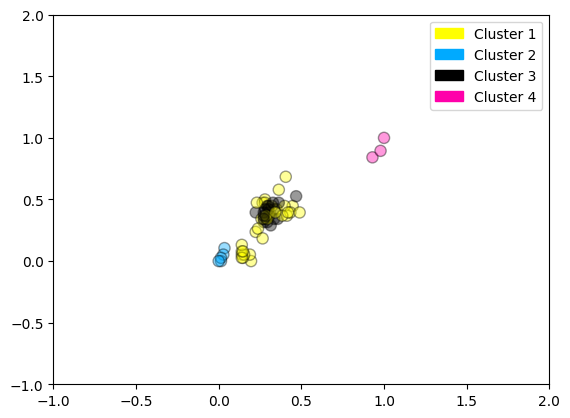

In [7]:
from sklearn.datasets import make_blobs  # (No se usa en este bloque, se podría eliminar si se desea limpiar el código)
from sklearn.cluster import KMeans       # Importa el algoritmo KMeans para clustering no supervisado.
from shared_utilities import plot_labelled_scatter  # Función externa que grafica los datos según sus etiquetas.
from sklearn.preprocessing import MinMaxScaler       # Escalador para normalizar características numéricas.
import pandas as pd                                  # Librería para manipulación de datos tabulares.

# URL del archivo de datos: contiene información de frutas con características físicas y color.
uu = 'https://raw.githubusercontent.com/vmoprojs/DataLectures/refs/heads/master/fruit_data_with_colors.txt'

# Carga los datos en un DataFrame. El archivo es de texto con separador de tabulaciones (\t).
fruits = pd.read_table(uu)

# Selecciona las variables numéricas relevantes para el modelo de clustering y las convierte en matriz NumPy.
X_fruits = fruits[['mass','width','height', 'color_score']].to_numpy()

# Obtiene las etiquetas verdaderas (por tipo de fruta) y las ajusta para comenzar desde 0. No se usan en el clustering.
y_fruits = fruits[['fruit_label']] - 1

# Normaliza los datos a un rango [0, 1] para que todas las variables tengan igual peso en el clustering.
scaler_fruits = MinMaxScaler()
X_fruits_normalized = scaler_fruits.fit_transform(X_fruits)

# Crea el modelo KMeans para 4 clústeres y utiliza varias inicializaciones.
kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)

# Ajusta el modelo a los datos normalizados. El algoritmo agrupa las observaciones en 4 clústeres.
kmeans.fit(X_fruits_normalized)

# Grafica los resultados, coloreando cada punto según el clúster asignado y con etiquetas personalizadas.
plot_labelled_scatter(X_fruits_normalized, kmeans.labels_,
                      ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])


## K-medoides

K-medoides es un método de partición similar a K-means, pero representa cada clúster mediante una **observación real del conjunto de datos**, denominada medoide. Su criterio general es minimizar la suma de disimilitudes entre cada observación y el medoide de su grupo:

$$
J_{\text{medoides}}
=
\sum_{k=1}^{K}
\sum_{\mathbf{x}_i\in C_k}
d(\mathbf{x}_i,\mathbf{m}_k),
$$

donde $\mathbf{m}_k\in C_k$ es el medoide del clúster $k$.

Esta característica hace que K-medoides sea, en general, más resistente a valores atípicos que K-means y permite utilizar distintas métricas de distancia.

**Parámetros principales de `KMedoids`:**

```python
KMedoids(
    n_clusters=8,
    metric="euclidean",
    method="pam",
    init="heuristic",
    max_iter=300,
    random_state=None
)
```

**Atributos importantes:**

- `labels_`: asignación de clúster de cada observación;
- `cluster_centers_`: coordenadas de los medoides;
- `medoid_indices_`: posiciones de las observaciones elegidas como medoides;
- `inertia_`: suma de distancias de las observaciones a su medoide más cercano.

### Algoritmo, en términos generales

1. Seleccionar $K$ observaciones iniciales como medoides.
2. Asignar cada observación al medoide más cercano.
3. Probar intercambios entre medoides y no medoides.
4. Conservar los intercambios que reduzcan el costo total.
5. Detenerse cuando ningún intercambio mejore la solución.


### Definición matemática de medoide en $\mathbb{R}^d$

Sea $C\subseteq\mathbf{X}$ un clúster. El medoide $\mathbf{x}_m\in C$ es la observación que minimiza la suma de distancias al resto de elementos del grupo:

$$
\mathbf{x}_m
=
\arg\min_{\mathbf{x}_i\in C}
\sum_{\mathbf{x}_j\in C}
d(\mathbf{x}_i,\mathbf{x}_j).
$$

Si se utiliza distancia euclidiana,

$$
d(\mathbf{x}_i,\mathbf{x}_j)
=
\left\|\mathbf{x}_i-\mathbf{x}_j\right\|_2
=
\sqrt{\sum_{r=1}^{d}(x_{ir}-x_{jr})^2}.
$$

A diferencia del centroide de K-means, el medoide siempre pertenece al conjunto observado. No debe confundirse con un vector formado por las medianas de las variables.


### Ejemplo sencillo: cálculo manual de un medoide

Considere un clúster unidimensional formado por cinco observaciones:

$$
C=\{1,2,3,8,10\}.
$$

Como los datos tienen una sola dimensión, utilizaremos la distancia absoluta:

$$
d(x_i,x_j)=|x_i-x_j|.
$$

Para identificar el medoide, se toma cada observación como candidata y se calcula la suma de sus distancias a todas las observaciones del clúster:

| Candidato | Cálculo de la suma de distancias | Suma total |
|---:|:---|---:|
| $1$ | $|1-1|+|1-2|+|1-3|+|1-8|+|1-10|$ | $19$ |
| $2$ | $|2-1|+|2-2|+|2-3|+|2-8|+|2-10|$ | $16$ |
| $3$ | $|3-1|+|3-2|+|3-3|+|3-8|+|3-10|$ | $15$ |
| $8$ | $|8-1|+|8-2|+|8-3|+|8-8|+|8-10|$ | $20$ |
| $10$ | $|10-1|+|10-2|+|10-3|+|10-8|+|10-10|$ | $26$ |

La menor suma de distancias es $15$, obtenida por la observación $3$. Por tanto,

$$
x_m=3.
$$

Así, **el medoide es la observación $3$**, porque es el punto observado que se encuentra, en términos globales, más cerca de los demás.

En contraste, el centroide utilizado por K-means sería la media:

$$
\bar{x}=\frac{1+2+3+8+10}{5}=4.8.
$$

El valor $4.8$ no pertenece al conjunto de datos, mientras que el medoide $3$ sí es una observación real. Esta es la diferencia esencial entre **centroide** y **medoide**.


In [8]:
# Ejemplo computacional del cálculo de un medoide
puntos = np.array([1, 2, 3, 8, 10], dtype=float)

# Matriz de distancias absolutas entre todos los pares de observaciones
matriz_distancias = np.abs(puntos[:, None] - puntos[None, :])

# Suma de distancias desde cada observación hacia las demás
suma_distancias = matriz_distancias.sum(axis=1)

# La observación con la menor suma de distancias es el medoide
indice_medoide = np.argmin(suma_distancias)
medoide = puntos[indice_medoide]

etiquetas = [f"x = {int(x)}" for x in puntos]
tabla_distancias = pd.DataFrame(
    matriz_distancias,
    index=etiquetas,
    columns=etiquetas
)
tabla_distancias["Suma de distancias"] = suma_distancias

display(tabla_distancias)
print(f"Medoide: {medoide:g}")
print(f"Suma mínima de distancias: {suma_distancias[indice_medoide]:g}")


,x = 1,x = 2,x = 3,x = 8,x = 10,Suma de distancias
x = 1,0.0,1.0,2.0,7.0,9.0,19.0
x = 2,1.0,0.0,1.0,6.0,8.0,16.0
x = 3,2.0,1.0,0.0,5.0,7.0,15.0
x = 8,7.0,6.0,5.0,0.0,2.0,20.0
x = 10,9.0,8.0,7.0,2.0,0.0,26.0


Medoide: 3
Suma mínima de distancias: 15


In [9]:
# https://scikit-learn-extra.readthedocs.io/en/latest/index.html
# Documentación oficial del paquete scikit-learn-extra, que amplía scikit-learn con algoritmos adicionales.

from sklearn_extra.cluster import KMedoids
# Importa el algoritmo K-Medoids, una alternativa a KMeans que elige observaciones reales como representantes de cada clúster (medoides).

# Crea el modelo de clustering con K-Medoids para 4 grupos y semilla fija para reproducibilidad.
kmedoides = KMedoids(n_clusters=4, metric="euclidean", method="pam", random_state=42)

# Ajusta el modelo a los datos previamente normalizados. Cada punto es asignado al medoide más cercano.
kmedoides.fit(X_fruits_normalized)

# Grafica los resultados del clustering, coloreando los puntos según su grupo asignado por K-Medoids.
# Usa etiquetas personalizadas para los 4 clústeres.
plot_labelled_scatter(X_fruits_normalized, kmedoides.labels_,
                      ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])


ModuleNotFoundError: No module named 'sklearn_extra'

In [ ]:
# Comparar las asignaciones obtenidas por K-means y K-medoides
tabla_cruzada = pd.crosstab(kmeans.labels_, kmedoides.labels_,
                             rownames=["KMeans"], colnames=["KMedoids"])

print(tabla_cruzada)

## Clustering jerárquico aglomerativo

El clustering jerárquico construye una secuencia de particiones anidadas. En su versión **aglomerativa**, cada observación comienza como un clúster independiente y los grupos más similares se fusionan progresivamente.

El resultado completo puede representarse mediante un **dendrograma**, que permite explorar distintas cantidades de clústeres después de construir la jerarquía. No obstante, al utilizar `AgglomerativeClustering` para obtener una partición concreta, debe fijarse `n_clusters` o establecerse un `distance_threshold`.

La forma final de la jerarquía depende de:

- la métrica utilizada para comparar observaciones;
- el criterio de enlace utilizado para medir la distancia entre clústeres;
- la escala de las variables.


### Algoritmo

**Entrada:** un conjunto de observaciones y una regla para medir la disimilitud entre grupos.

**Procedimiento:**

1. Considerar inicialmente cada observación como un clúster.
2. Calcular las distancias entre todos los pares de clústeres.
3. Fusionar los dos clústeres más próximos.
4. Actualizar las distancias de acuerdo con el criterio de enlace.
5. Registrar la fusión en el dendrograma.
6. Repetir hasta que todas las observaciones formen un único grupo.

Un corte horizontal del dendrograma produce una partición. Cuanto más alto se realice el corte, menor será el número de clústeres.


**Parámetros principales de `AgglomerativeClustering`:**

```python
AgglomerativeClustering(
    n_clusters=2,              # Número de clústeres de la partición final
    metric="euclidean",        # Métrica entre observaciones
    linkage="ward",            # "ward", "complete", "average" o "single"
    compute_full_tree="auto",
    distance_threshold=None,   # Alternativa a n_clusters
    compute_distances=False
)
```

Cuando `linkage="ward"`, la métrica debe ser euclidiana porque el método minimiza el incremento de la suma de cuadrados dentro de los grupos.

**Atributos importantes:**

| Atributo | Descripción |
|---|---|
| `labels_` | Etiqueta de clúster asignada a cada observación |
| `n_clusters_` | Número final de clústeres |
| `n_leaves_` | Número de hojas del árbol |
| `n_connected_components_` | Número de componentes de conectividad |
| `children_` | Pares de nodos fusionados en cada etapa |
| `distances_` | Distancias de fusión, cuando se calculan |


En Python, el método [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) nos permite ejecutar clustering jerárquico.

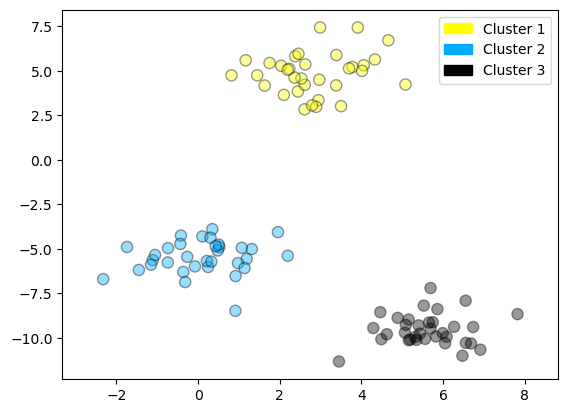

In [ ]:
from sklearn.datasets import make_blobs  # Genera datos sintéticos con distribución en forma de clústeres.
from sklearn.cluster import AgglomerativeClustering  # Importa el algoritmo de clustering jerárquico aglomerativo.
from shared_utilities import plot_labelled_scatter  # Función para graficar los datos coloreados por clúster.

# Genera un conjunto de datos de ejemplo con clústeres definidos.
# X contiene las coordenadas de los puntos, y son las etiquetas reales (no se usan en el clustering).
X, y = make_blobs(random_state=10)

# Crea un modelo de agrupamiento jerárquico aglomerativo con 3 clústeres deseados.
cls = AgglomerativeClustering(n_clusters=3)

# Ajusta el modelo a los datos y devuelve las asignaciones de clúster para cada punto.
cls_assignment = cls.fit_predict(X)

# Grafica los datos, coloreando cada punto según el clúster asignado por el modelo.
# Se añaden etiquetas personalizadas para facilitar la interpretación visual.
plot_labelled_scatter(X, cls_assignment, 
                      ['Cluster 1', 'Cluster 2', 'Cluster 3'])


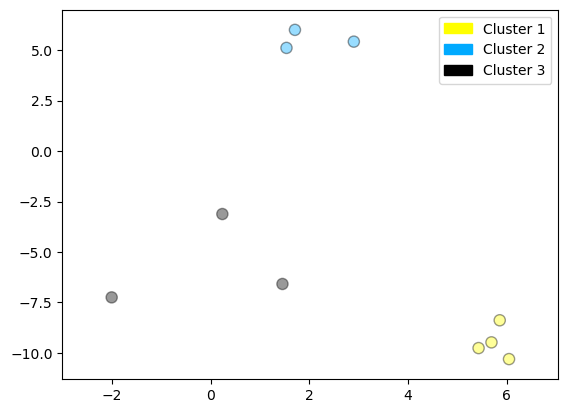

[[  5.69192445  -9.47641249]
 [  1.70789903   6.00435173]
 [  0.23621041  -3.11909976]
 [  2.90159483   5.42121526]
 [  5.85943906  -8.38192364]
 [  6.04774884 -10.30504657]
 [ -2.00758803  -7.24743939]
 [  1.45467725  -6.58387198]
 [  1.53636249   5.11121453]
 [  5.4307043   -9.75956122]]


In [ ]:
X, y = make_blobs(random_state = 10, n_samples = 10)
plot_labelled_scatter(X, y, 
        ['Cluster 1', 'Cluster 2', 'Cluster 3'])
print(X)

### Construcción del dendrograma


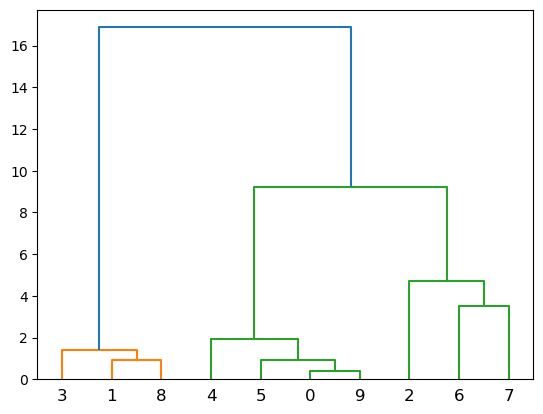

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
plt.figure()
dendrogram(linkage(X, 'complete'))
plt.show()

-   Cada hoja del dendrograma representa una de las $n$ observaciones.

-   A medida que subimos por el árbol, algunas hojas comienzan a *fusionarse* en ramas. Estos corresponden a observaciones que son similares entre sí.

-   Cuanto antes (más abajo en el árbol) se produzcan fusiones, más similares serán los grupos de observaciones entre sí. Por otro lado, las observaciones que se fusionan más tarde (cerca de la parte superior del árbol) pueden ser bastante diferentes.


-   La altura de esta fusión, medida en el eje vertical, **indica cuán diferentes son las dos observaciones**. Por lo tanto, las observaciones que se fusionan en la parte inferior del árbol son bastante similares entre sí, mientras que las observaciones que se fusionan cerca de la parte superior del árbol tenderán a ser bastante diferentes.

### Criterios de enlace para fusionar grupos

<img src="images/10_fig1.png" width="500" height="300">

- **Complete:** utiliza la mayor distancia entre pares de observaciones pertenecientes a dos clústeres. Tiende a producir grupos compactos.
- **Single:** utiliza la menor distancia entre pares. Puede generar el efecto de encadenamiento.
- **Average:** utiliza el promedio de las distancias entre todos los pares.
- **Centroid:** utiliza la distancia entre los centroides de los clústeres.
- **Ward:** fusiona los grupos que generan el menor incremento en la suma de cuadrados interna.


En **Python** usamos los métodos:

- [dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html): para elaborar el dendograma.

- [linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html): Realiza agrupamiento jerárquico/aglomerativo.

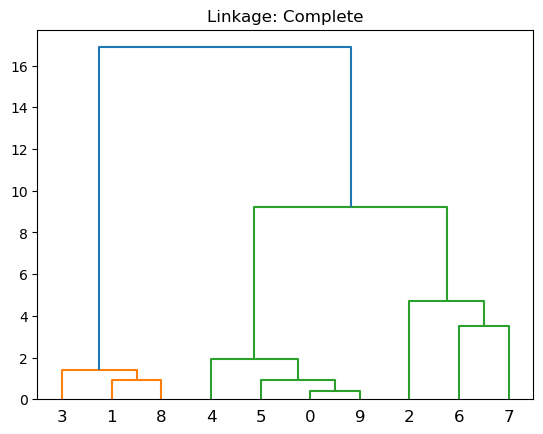

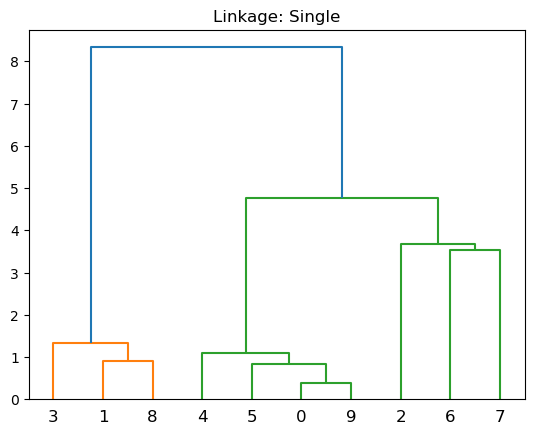

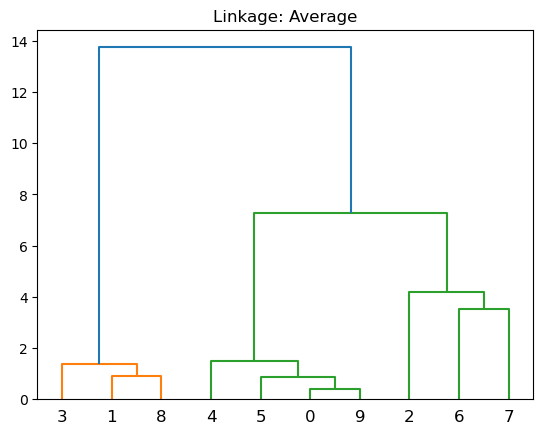

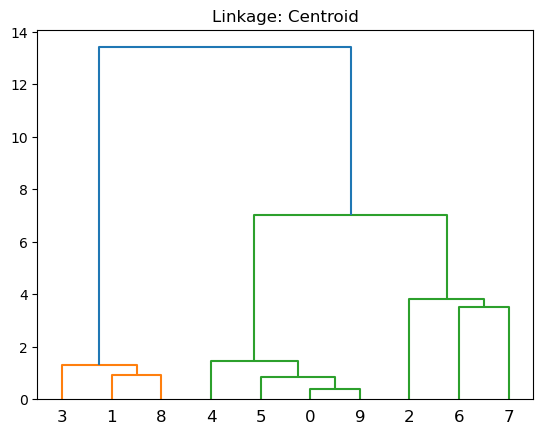

In [ ]:
plt.figure()
plt.title('Linkage: Complete')
dendrogram(linkage(X, 'complete'))
plt.show()

plt.figure()
plt.title('Linkage: Single')
dendrogram(linkage(X, 'single'))
plt.show()

plt.figure()
plt.title('Linkage: Average')
dendrogram(linkage(X, 'average'))
plt.show()

plt.figure()
plt.title('Linkage: Centroid')
dendrogram(linkage(X, 'centroid'))
plt.show()

## DBSCAN: clustering basado en densidad


DBSCAN identifica regiones densas separadas por regiones de baja densidad. A diferencia de K-means, puede encontrar clústeres con formas arbitrarias y clasificar ciertas observaciones como **ruido**.

Sus parámetros principales son:

- $\varepsilon$ (`eps`): radio de la vecindad alrededor de cada observación;
- `min_samples`: número mínimo de observaciones requerido para considerar que una región es suficientemente densa.

La vecindad cerrada de radio $\varepsilon$ alrededor de una observación $\mathbf{x}_i$ es

$$
N_{\varepsilon}(\mathbf{x}_i)
=
\left\{
\mathbf{x}_j\in\mathbf{X}:
d(\mathbf{x}_i,\mathbf{x}_j)\leq\varepsilon
\right\}.
$$

Una observación puede ser:

- **punto núcleo:** contiene al menos `min_samples` observaciones en su vecindad;
- **punto frontera:** no es núcleo, pero pertenece a la vecindad de un punto núcleo;
- **ruido:** no es alcanzable desde ninguna región densa y recibe la etiqueta `-1`.

DBSCAN no requiere fijar previamente el número de clústeres, pero es sensible a la escala de las variables y a la elección de $\varepsilon$ y `min_samples`.


<img src="images/dbscan.jpg" width="500" height="300">

En Python, `DBSCAN` permite ejecutar el algoritmo. Después de `fit_predict`, las etiquetas no negativas identifican clústeres y la etiqueta `-1` identifica ruido.


Cluster membership values:
[ 0  1  0  2  0  0  0  2  2 -1  1  2  0  0 -1  0  0  1 -1  1  1  2  2  2
  1]


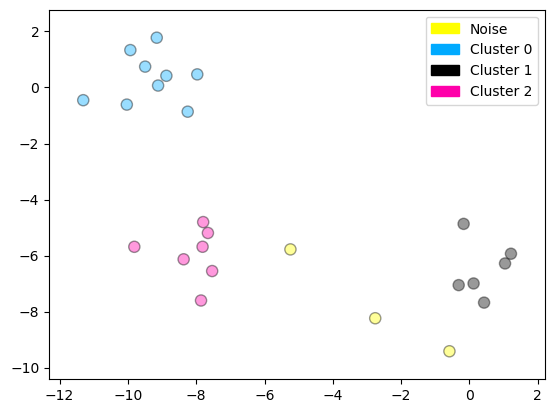

In [ ]:
from sklearn.cluster import DBSCAN  # Importa el algoritmo DBSCAN para clustering basado en densidad.
from sklearn.datasets import make_blobs  # Función para generar datos sintéticos agrupados.

# Genera un conjunto de 25 puntos con estructura de clúster para pruebas.
# X: coordenadas de los puntos, y: etiquetas reales (no se usan aquí).
X, y = make_blobs(random_state=9, n_samples=25)

# Crea el modelo DBSCAN con parámetros:
# eps = 2: radio de vecindad considerado para formar un clúster.
# min_samples = 2: número mínimo de puntos para formar un clúster denso.
dbscan = DBSCAN(eps=2, min_samples=2)

# Ajusta el modelo y obtiene las etiquetas de clúster (o -1 si el punto es ruido).
cls = dbscan.fit_predict(X)

# Imprime los valores de pertenencia a clúster de cada punto.
# -1 representa ruido (puntos que no pertenecen a ningún clúster).
print("Cluster membership values:\n{}".format(cls))

# Grafica los resultados del clustering.
# Se le suma 1 a las etiquetas para que el ruido (-1) pase a 0 y así pueda graficarse como "Noise".
# Etiquetas: 'Noise' para los puntos aislados, y 'Cluster 0', 'Cluster 1', etc., para los demás.
plot_labelled_scatter(X, cls + 1, 
                      ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2'])


### Ejemplo: clasificación de clientes

In [ ]:
uu = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/Mall_Customers.csv"
datos = pd.read_csv(uu)


dbDat = datos.iloc[:,3:5]
dbDat.describe()

,AnnualIncome,SpendingScore
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


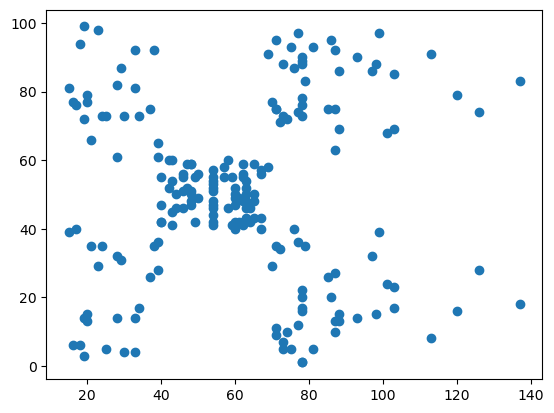

In [ ]:
plt.figure()
plt.scatter(dbDat.AnnualIncome,dbDat.SpendingScore)
plt.show()

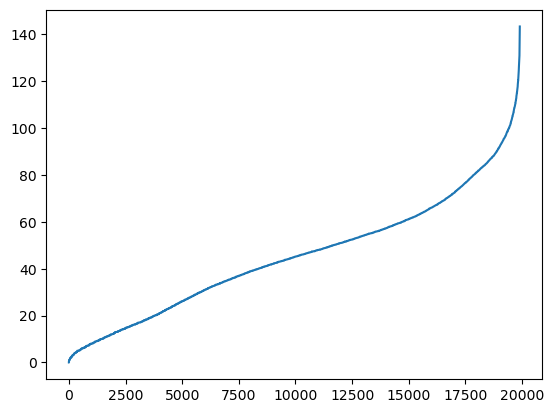

In [ ]:
from scipy.spatial import distance_matrix
dd = pd.DataFrame(distance_matrix(dbDat.values, dbDat.values), index=dbDat.index, columns=dbDat.index)
n = len(np.sort(dd.values))
dd = np.sort(dd.values[np.triu_indices(n, k = 1)])

plt.figure()
plt.plot(dd)
plt.show()

Cluster membership values:
[ 0  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  2  0  2  0  2  3  2  3  2  0  2  3  2  3  2  3  2  3  2  0  2
  3  2  0  2  3  2  3  2  3  2  3  2  3  2  3  2  0  2  3  2  3  2  3  2
  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3 -1  3  2  3 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


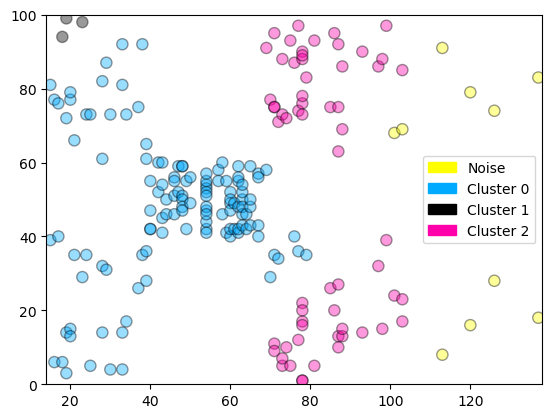

In [ ]:
dbscan = DBSCAN(eps = 10, min_samples = 3)

cls = dbscan.fit_predict(dbDat)
print("Cluster membership values:\n{}".format(cls))

plot_labelled_scatter(dbDat.values, cls + 1, 
        ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2'])


## Ejemplo integrador: reducción de dimensión y clustering

En el siguiente ejemplo se estandarizan indicadores de criminalidad, se resumen mediante dos componentes principales y se aplican métodos de clustering sobre la misma representación bidimensional. Trabajar sobre un espacio común permite comparar visualmente las soluciones, aunque la reducción mediante ACP puede descartar parte de la información original.


In [ ]:
www = "https://stat.ethz.ch/Teaching/Datasets/WBL/crime2.dat"
crime = pd.read_csv(www, sep=r"\s+")
crime.describe()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Antes de aplicar ACP, cada variable debe ser centrada y de varianza igual a 1
X_normalized = StandardScaler().fit(crime).transform(crime) 

In [ ]:
from sklearn.decomposition import PCA  # Importa el algoritmo de reducción de dimensionalidad PCA.
from sklearn.cluster import KMeans     # Importa el algoritmo KMeans para clustering.

# Aplica PCA (Análisis de Componentes Principales) para reducir los datos normalizados a 2 dimensiones.
# Esto permite visualizar mejor los datos y eliminar redundancias entre variables.
pca = PCA(n_components=2).fit(X_normalized)

# Transforma los datos originales normalizados al nuevo espacio de 2 componentes principales.
X_pca = pca.transform(X_normalized)  # Matriz con las dos nuevas variables principales.

# Imprime cuánta varianza explican los dos primeros componentes.
# Esto indica qué porcentaje de la información original se mantiene en la reducción.
print('Varianza explicada:', pca.explained_variance_ratio_)

# Crea el modelo KMeans para 3 clústeres y lo ajusta sobre los datos ya transformados con PCA.
grupos = KMeans(n_clusters=3, n_init=20, random_state=42)
grupos.fit(X_pca)

# Grafica los datos en el espacio reducido (PCA), coloreados según los clústeres asignados por KMeans.
plot_labelled_scatter(X_pca, grupos.labels_, ['Cluster 1', 'Cluster 2', 'Cluster 3'])


[-1  0  1  2]


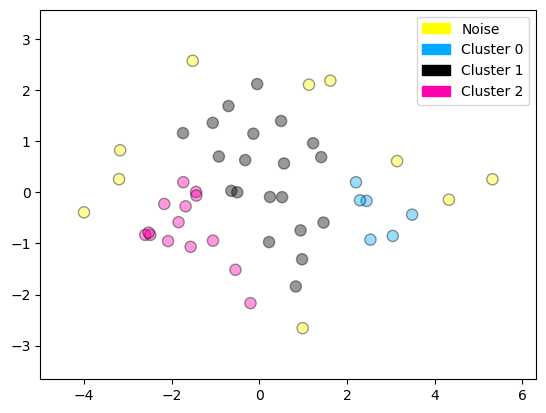

In [ ]:
from sklearn.cluster import DBSCAN  # Importa el algoritmo DBSCAN (clustering basado en densidad).
import numpy as np                  # Importa NumPy para manipulación de arrays.

# Crea el modelo DBSCAN con parámetros ajustados:
# eps = 0.8: radio de vecindad para considerar puntos como vecinos.
# min_samples = 3: mínimo número de vecinos (incluyéndose) para que un punto sea considerado núcleo de un clúster.
dbscan = DBSCAN(eps=0.8, min_samples=3)

# Ajusta el modelo sobre los datos reducidos a 2D con PCA.
# Devuelve etiquetas de clúster para cada punto, donde -1 indica puntos ruidosos (no agrupados).
cls = dbscan.fit_predict(X_pca)

# Imprime las etiquetas únicas asignadas por DBSCAN (por ejemplo: [-1, 0, 1] si hay ruido y dos clústeres).
print(np.unique(cls))

# Grafica los puntos en el espacio reducido (PCA), sumando 1 a las etiquetas para que el ruido (-1) pase a 0.
# Esto permite graficar correctamente el ruido con la etiqueta 'Noise', y los demás como 'Cluster 0', 'Cluster 1', etc.
plot_labelled_scatter(X_pca, cls + 1,
                      ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2'])


## Evaluación interna de las agrupaciones

Cuando no se dispone de etiquetas verdaderas, la calidad de una partición puede analizarse mediante **índices internos**. Estos índices utilizan únicamente las características y las asignaciones de clúster.

### Coeficiente de Silueta

Para una observación $i$, sea:

- $a(i)$: distancia promedio entre $i$ y las observaciones de su propio clúster;
- $b(i)$: menor distancia promedio entre $i$ y las observaciones de cualquier otro clúster.

La silueta individual se define como

$$
s(i)
=
\frac{b(i)-a(i)}
{\max\{a(i),b(i)\}}.
$$

El coeficiente global es el promedio de $s(i)$ y toma valores entre $-1$ y $1$:

- valores cercanos a $1$: observaciones bien asignadas y clústeres separados;
- valores cercanos a $0$: clústeres superpuestos;
- valores negativos: posibles asignaciones incorrectas.

### Índice de Calinski–Harabasz

El índice de Calinski–Harabasz compara la dispersión entre clústeres con la dispersión dentro de los clústeres:

$$
CH
=
\frac{B_K/(K-1)}
{W_K/(n-K)},
$$

donde $B_K$ representa la dispersión entre grupos, $W_K$ la dispersión interna, $K$ el número de clústeres y $n$ el número de observaciones.

Un valor mayor indica clústeres más compactos y mejor separados. El índice no está acotado, por lo que debe compararse únicamente entre soluciones construidas sobre el mismo conjunto de datos y la misma representación de variables.

### Consideración especial para DBSCAN

DBSCAN puede generar ruido con etiqueta `-1`. En la comparación siguiente, Silueta y Calinski–Harabasz se calculan sobre las observaciones asignadas a clústeres, mientras que el porcentaje de ruido se reporta por separado. Si DBSCAN produce menos de dos clústeres válidos, los índices no pueden calcularse.


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from IPython.display import display


def evaluar_agrupamiento(X, etiquetas, metodo, excluir_ruido=True):
    """Calcula métricas internas y resume la cobertura de una solución de clustering."""
    X = np.asarray(X)
    etiquetas = np.asarray(etiquetas)

    es_ruido = etiquetas == -1
    n_ruido = int(es_ruido.sum())

    if excluir_ruido:
        mascara = ~es_ruido
    else:
        mascara = np.ones(len(etiquetas), dtype=bool)

    X_eval = X[mascara]
    etiquetas_eval = etiquetas[mascara]
    grupos_validos = np.unique(etiquetas_eval)
    n_clusters = len(grupos_validos)

    # Silueta y CH requieren al menos dos clústeres y más observaciones que grupos.
    puede_evaluarse = (
        n_clusters >= 2
        and len(X_eval) > n_clusters
    )

    if puede_evaluarse:
        silueta = silhouette_score(X_eval, etiquetas_eval)
        ch = calinski_harabasz_score(X_eval, etiquetas_eval)
        nota = ""
    else:
        silueta = np.nan
        ch = np.nan
        nota = "No se pueden calcular los índices: se requieren al menos dos clústeres válidos."

    return {
        "Método": metodo,
        "Clústeres": n_clusters,
        "Observaciones evaluadas": len(X_eval),
        "Ruido (%)": 100 * n_ruido / len(etiquetas),
        "Silueta": silueta,
        "Calinski-Harabasz": ch,
        "Nota": nota
    }


In [ ]:
# Los tres métodos se evalúan sobre la misma representación: las dos componentes principales.
modelos = {
    "K-means": KMeans(n_clusters=3, n_init=20, random_state=42),
    "Aglomerativo (Ward)": AgglomerativeClustering(n_clusters=3, linkage="ward"),
    "DBSCAN": DBSCAN(eps=0.8, min_samples=3)
}

resultados = []
etiquetas_modelos = {}

for nombre, modelo in modelos.items():
    etiquetas = modelo.fit_predict(X_pca)
    etiquetas_modelos[nombre] = etiquetas
    resultados.append(
        evaluar_agrupamiento(
            X_pca,
            etiquetas,
            metodo=nombre,
            excluir_ruido=True
        )
    )

evaluacion_clustering = (
    pd.DataFrame(resultados)
    .sort_values("Silueta", ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(
    evaluacion_clustering.style.format({
        "Ruido (%)": "{:.1f}",
        "Silueta": "{:.3f}",
        "Calinski-Harabasz": "{:.2f}"
    })
)

resultados_validos = evaluacion_clustering.dropna(subset=["Silueta"])

if not resultados_validos.empty:
    mejor_silueta = resultados_validos.loc[resultados_validos["Silueta"].idxmax(), "Método"]
    mejor_ch = resultados_validos.loc[resultados_validos["Calinski-Harabasz"].idxmax(), "Método"]

    print(f"Mayor Silueta: {mejor_silueta}")
    print(f"Mayor índice de Calinski–Harabasz: {mejor_ch}")
else:
    print("Ninguna solución produjo al menos dos clústeres evaluables.")


### Cómo interpretar la comparación

Una solución será más convincente cuando alcance valores relativamente altos en ambos índices y, además, tenga sentido sustantivo y visual.

No siempre ambos indicadores elegirán el mismo método. Esto no constituye un error: cada índice resume la estructura de los grupos de manera diferente. Además, una buena puntuación interna no garantiza que los clústeres sean útiles para el problema aplicado.

En DBSCAN también debe considerarse la **cobertura**. Un valor elevado de Silueta obtenido después de excluir una gran proporción de ruido puede describir muy bien únicamente una fracción pequeña de los datos. Por ello, los índices deben analizarse junto con el porcentaje de ruido y la visualización de la solución.


## Ejercicio aplicado: evaluación del clustering de frutas

Utilice `X_fruits_normalized`, definido en el ejemplo anterior, para comparar K-means, clustering aglomerativo y DBSCAN.

### Actividades

1. Ajuste K-means con $K=4$.
2. Ajuste clustering aglomerativo con $K=4$ y enlace de Ward.
3. Ajuste DBSCAN. Comience con `eps=0.20` y `min_samples=3`; luego pruebe al menos tres combinaciones adicionales.
4. Utilice la función `evaluar_agrupamiento` para calcular Silueta y Calinski–Harabasz.
5. Reporte el número de clústeres y el porcentaje de ruido.
6. Seleccione la solución que considere más adecuada y justifique su decisión.

Las etiquetas `y_fruits` no deben utilizarse para formar los clústeres. Pueden consultarse únicamente al final para interpretar si los grupos obtenidos guardan relación con los tipos de fruta.


In [ ]:
# Parámetros iniciales. Modifique eps_frutas y min_samples_frutas
# para estudiar la sensibilidad de DBSCAN.
eps_frutas = 0.20
min_samples_frutas = 3

modelos_frutas = {
    "K-means": KMeans(n_clusters=4, n_init=20, random_state=42),
    "Aglomerativo (Ward)": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    "DBSCAN": DBSCAN(eps=eps_frutas, min_samples=min_samples_frutas)
}

resultados_frutas = []

for nombre, modelo in modelos_frutas.items():
    etiquetas = modelo.fit_predict(X_fruits_normalized)
    resultados_frutas.append(
        evaluar_agrupamiento(
            X_fruits_normalized,
            etiquetas,
            metodo=nombre,
            excluir_ruido=True
        )
    )

evaluacion_frutas = (
    pd.DataFrame(resultados_frutas)
    .sort_values("Silueta", ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(
    evaluacion_frutas.style.format({
        "Ruido (%)": "{:.1f}",
        "Silueta": "{:.3f}",
        "Calinski-Harabasz": "{:.2f}"
    })
)


### Preguntas de reflexión

- ¿El método con mayor Silueta también presenta el mayor índice de Calinski–Harabasz?
- ¿Cómo cambia DBSCAN cuando aumenta o disminuye $\varepsilon$?
- ¿Qué ocurre con el porcentaje de ruido al modificar `min_samples`?
- ¿Es razonable comparar directamente un DBSCAN que evalúa pocas observaciones con métodos que asignan todas las frutas?
- ¿Los cuatro clústeres de K-means y del método aglomerativo coinciden necesariamente con las cuatro clases reales de frutas? Explique por qué.
